## Clustering

### Objective:
The objective of this assessment is to evaluate your understanding and ability to apply clustering
techniques to a real-world dataset.

In [16]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


### Load the Iris dataset from sklearn.

In [17]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Preprocessed dataset (species/target removed)
X = df.copy()
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### KMeans Clustering
How KMeans Works
KMeans partitions data into K clusters. It starts with K initial centroids, assigns each data point to the nearest centroid, updates centroid positions, and repeats until convergence.

Why KMeans is Suitable for the Iris Dataset

Iris contains naturally occurring groups of flowers.

Numerical features are continuous and suitable for distance-based clustering.

The dataset is relatively small and well-structured.

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster Labels:")
print(labels)

print("\nCentroids:")
print(centroids)

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]

Centroids:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


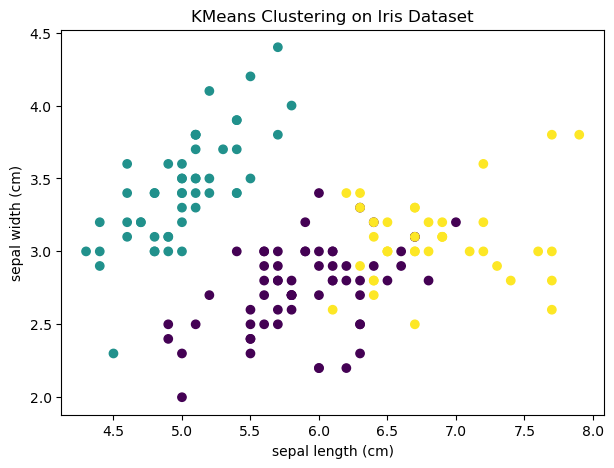

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=kmeans_labels)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('KMeans Clustering on Iris Dataset')
plt.show()


### Hierarchical Clustering
How Hierarchical Clustering Works
Hierarchical clustering builds a hierarchy of clusters. In agglomerative clustering, each point starts as its own cluster, and the closest clusters are merged repeatedly until the desired number of clusters is reached.

Why Hierarchical Clustering is Suitable for the Iris Dataset

Does not require random centroid initialization.

Reveals hierarchical relationships among samples.

Works well for small datasets such as Iris.

In [24]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

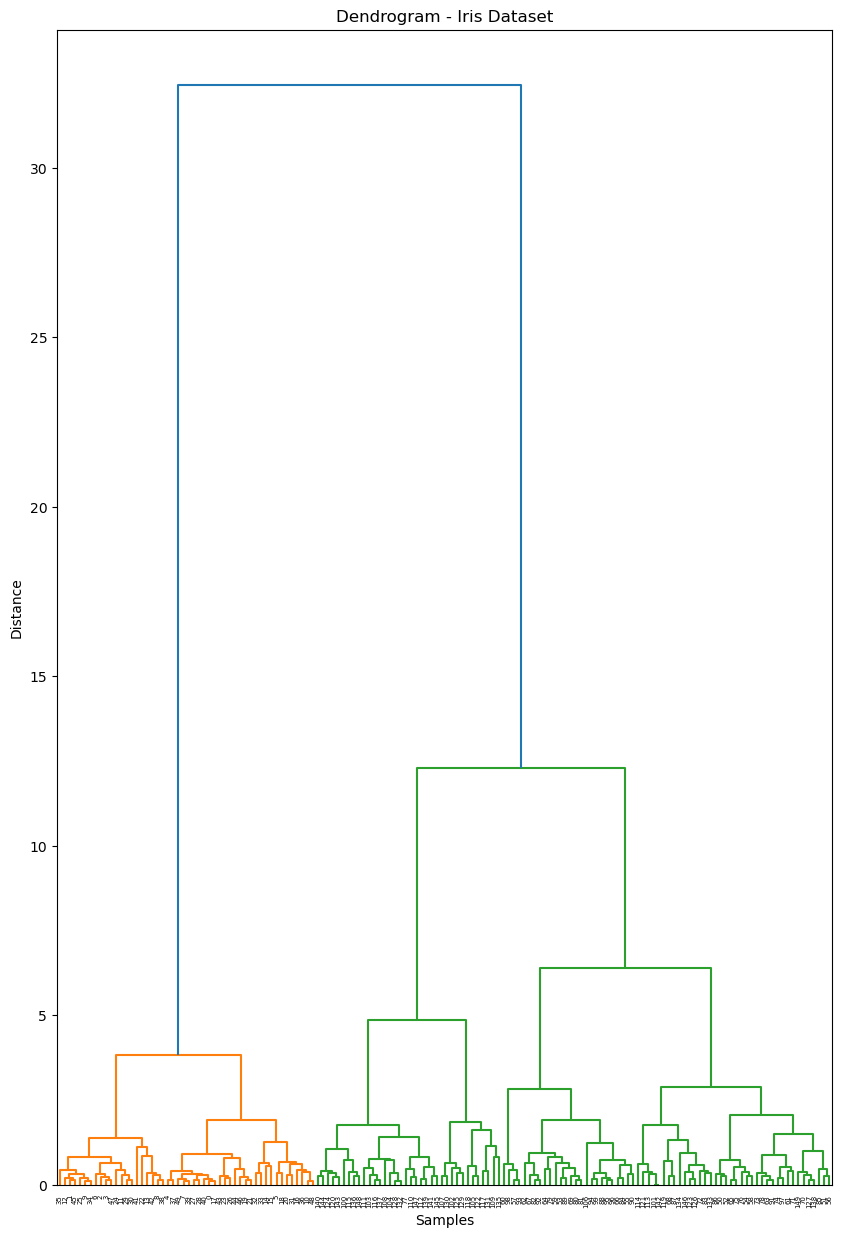

In [25]:
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 15))
dendrogram(linked)
plt.title("Dendrogram - Iris Dataset")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [32]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = model.fit_predict(X)
print(hc_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


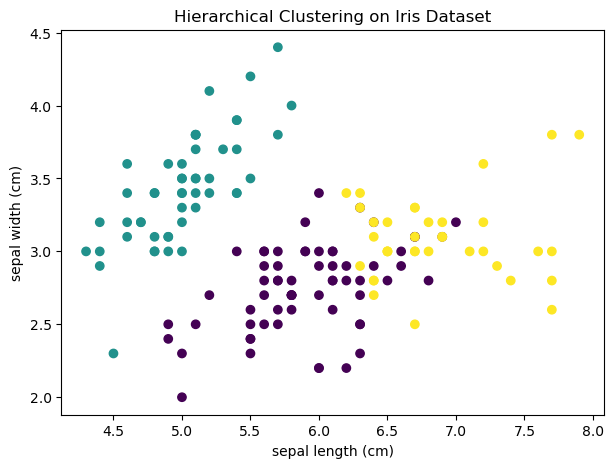

In [33]:
plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=hc_labels)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Hierarchical Clustering on Iris Dataset')
plt.show()

## Conclusion

Both KMeans and Hierarchical Clustering can identify natural groupings within the Iris dataset. KMeans is computationally efficient, while Hierarchical Clustering provides additional insight through the dendrogram structure.
